The following script demonstrates an analysis pipeline that may be applied to resulting CRAFT-Seq data. It utilizes post-alignment counts matrices for RNA and ADT, and per-cell allele tables produced by CRISPResso2. For creation of these processed files from raw FASTQs, please refer to example scripts outlined in the preprocessing section below.

For further exploration of the data used in this example, please refer to
[our full PTPRC notebook](../figures/PTPRC/PTPRC_Github.ipynb) where the example data was originally processed.

# 1. Preprocess FASTQs

1. [Align RNA](../preprocessing/RNAStep1_STARsolo.sh) FASTQs with STARsolo. [Consolidate results](../preprocessing/RNAStep2_LoadResults.R) into a single matrix for easy loading in R 

2. [Align ADT](../preprocessing/ADTStep1_KallistoKite.sh) FASTQs with Kallisto. Refer to [kallisto bustools](https://www.kallistobus.tools/kb_usage/kb_usage/) for creating your own custom ADT reference. [Consolidate results](../preprocessing/ADTStep2_LoadResults.R) into a single matrix for easy loading in R

3. Preprocess DNA FASTQs
    1. [Demultiplex](../preprocessing/DNAStep1_Demultiplex.sh) FASTQs so each contains read from a single cell in any given plate. This step is necessary in order to quantify alleles within a given single cell
    
    2. Align reads to an amplicon sequence with [CRISPResso2 Batch](../preprocessing/DNAStep2_CRISPRessoR2.sh). This allows us to process all the cells for any given plate at once
    
    3. [Reformat allele tables](../preprocessing/DNAStep3_AlleleTable.R) output by CRISPResso2 (1 for each cell) into a single allele table matrix for future analyses

# 2. Download processed data and load packages

Download example data for running this pipeline from Zenodo here: https://zenodo.org/records/15114923

In [1]:
source("../figures/DNA_filtering_Functions.R")
source("../misc_funcs.R")
library(Matrix)
library(MASS)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ tidyr::extract()     masks magrittr::extract()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ lubridate::quarter() masks data.table::quarter()
✖ lubridate::second()  masks data.table::second()
✖ purrr::set_names()   m

# 3. Genotype calling for DNA

Below is runnable code for calling genotype from CRISPREsso2 results. Please refer to [SupplementaryNote_Github.ipynb](../figures/SupplementaryNote/SupplementaryNote_Github.ipynb) for a detailed exploration of choices associated with genotype calling. Please refer to our Supplementary Note in the preprint manuscript for more complete explanations of these choices.

In [5]:
alleles = read_delim( "../../../Experiments/20230525/GithubExample/alleles_DNA_filt.csv") %>% as.data.frame

Rows: 6050 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): Well_ID, DNA_Barcode, Aligned_Sequence, cell_id, RNA_Barcode, Plate...
dbl (5): n_deleted, n_inserted, n_mutated, #Reads, %Reads

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


**Step 1.** Filter out cells with low read counts per plate. The plotted splines mark the point of curvature where cut off should be.

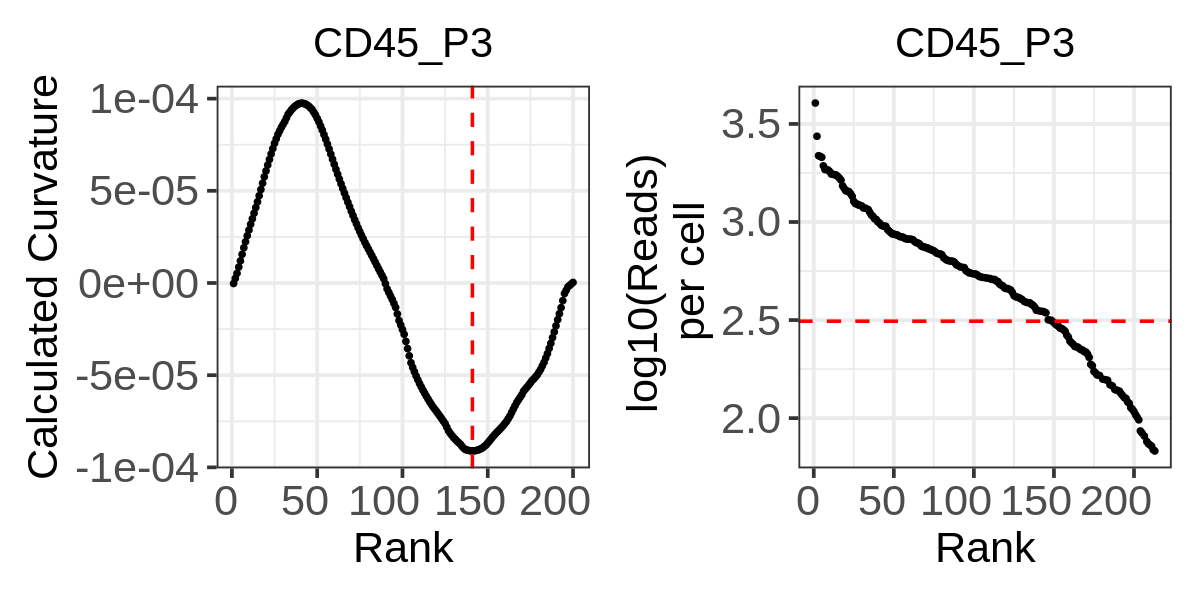

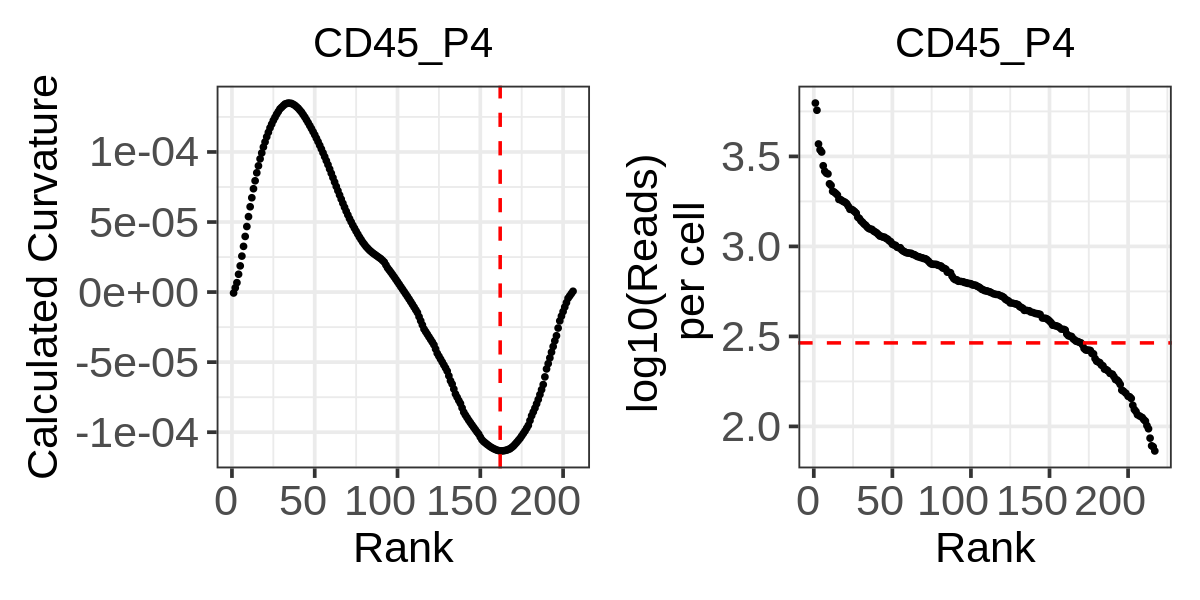

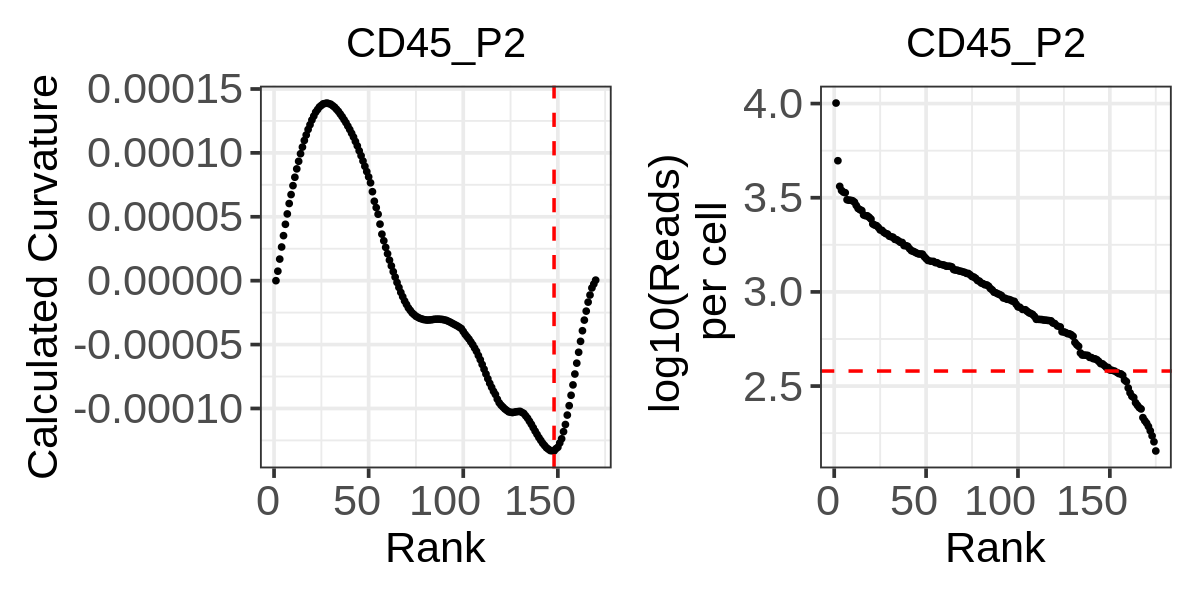

In [33]:
fig.size(5, 10)
alleles_filt = Filtering_Cells_Read(alleles, 'PlateLabel', 'cell_id')

**Step 2.** Remove alleles from sequencing artifacts. This involves a preliminary identification of alleles expressed per-cell and filtering out lowly expressed alleles (in <10-20% of reads for any given cell).

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


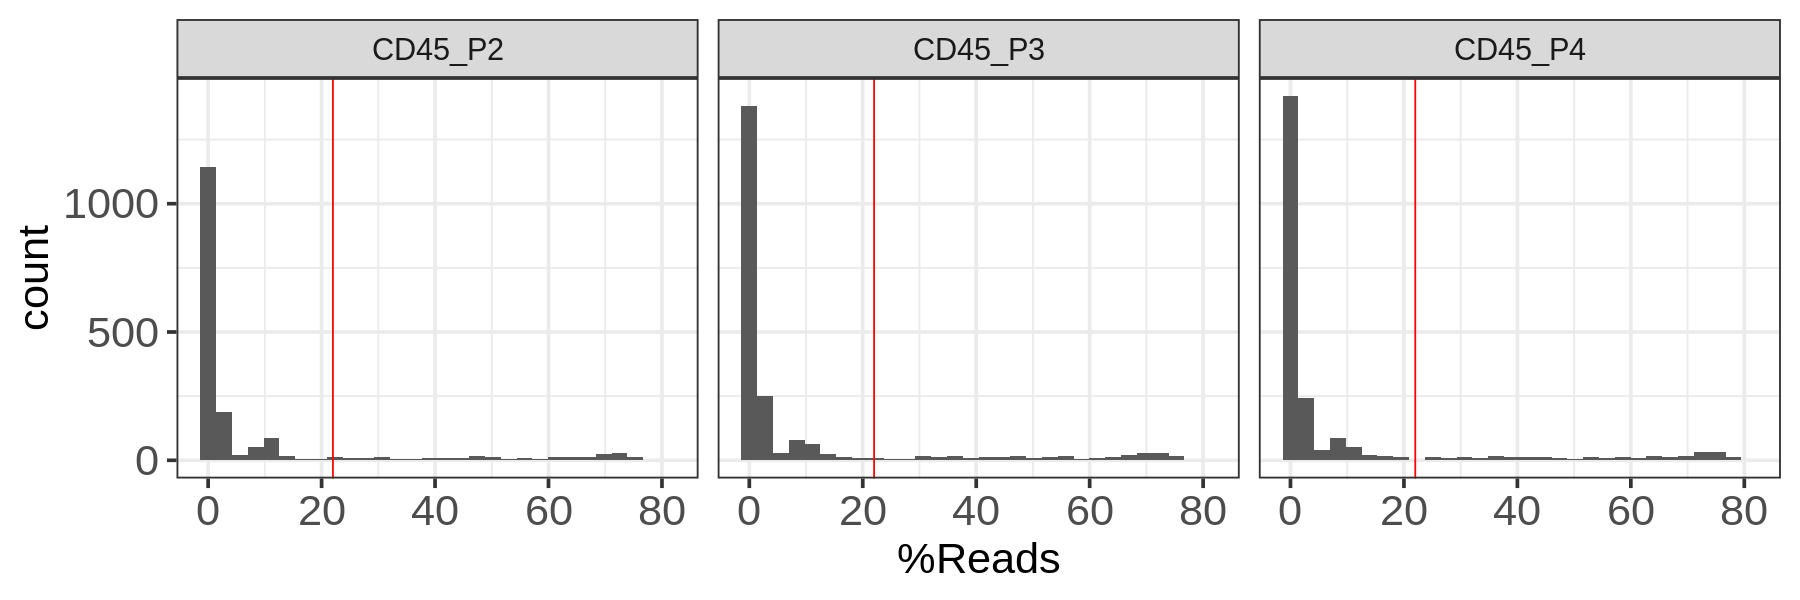

In [35]:
# Choose a filter cutoff to remove lowly expressed alleles 
fig.size(5,15)
alleles %>% 
    ggplot(aes(`%Reads`)) + geom_histogram() + 
    theme_gy() + geom_vline(xintercept = 22, color = "red") + facet_wrap(facets = ~PlateLabel, ncol = 5)

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


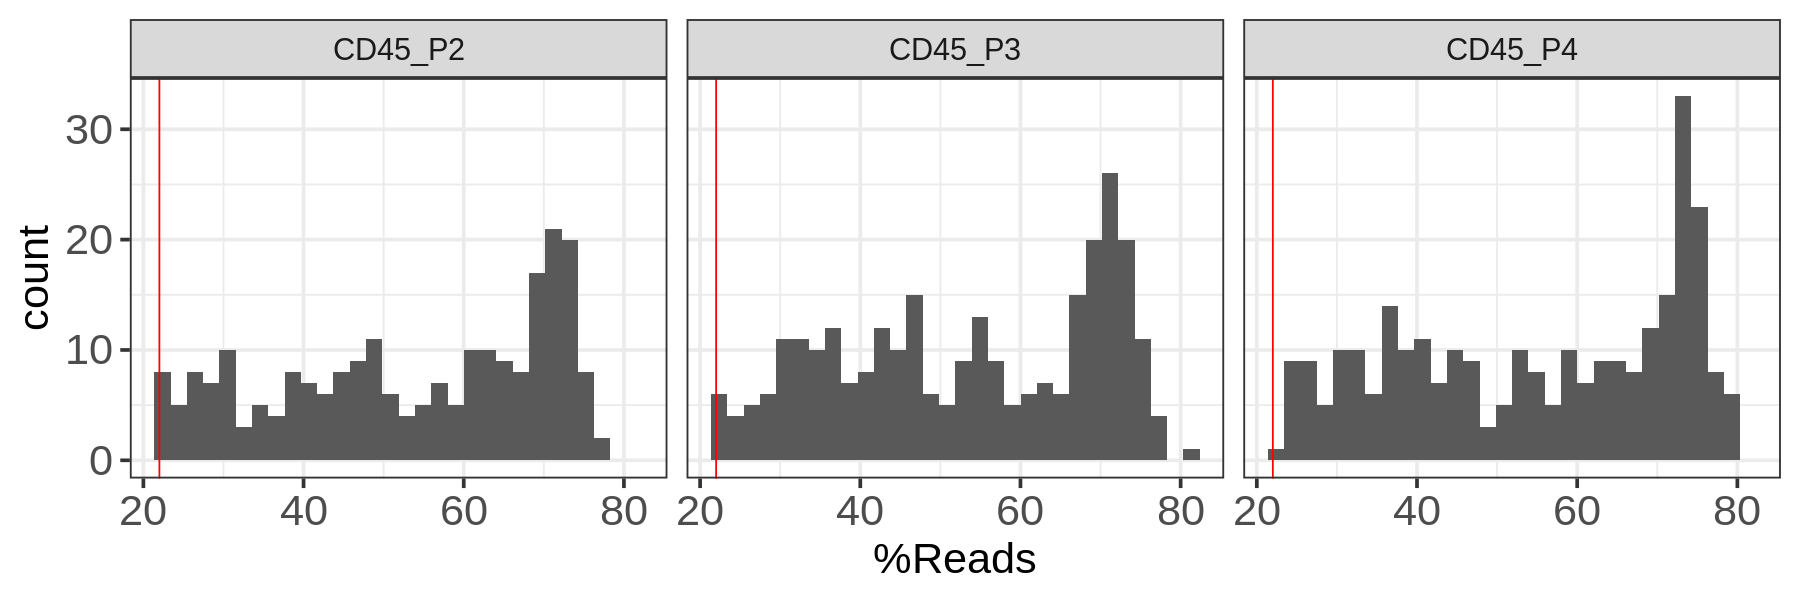

In [41]:
alleles_filt <- alleles %>% Filtering_Alleles('PlateLabel', 'cell_id', cutoff=22)

# Visualize remaining allele percentages
fig.size(5,15)
alleles_filt %>% 
    ggplot(aes(`%Reads`)) + geom_histogram() + 
    theme_gy() + geom_vline(xintercept = 22, color = "red") + facet_wrap(~PlateLabel)

**Step 3.** Call genotypes in each cell.

In [88]:
# Define reference amplicon for visualization and allele interpretation (optional)
reference = 'TAACAGGTCCAGGAGAGCCTCAGATTATTTTTTGTAGAAGTGAAGCTGCACATCAAGGAGTAATTACCTGGAATCCCCCTCAAAGATCATTTCATAATTTTACCCTCTGTTATATAAAAGAGACAGGTAATTTGTGTAGAATTTAATTTCATCAGAAAAGAGAAATCAAGAATTTGAAAGTACTA'

# Subset sequenced amplicon (and reference) to region of iterest 
alleles_filt <- alleles_filt %>%
    mutate(Aligned_Sequence = str_trunc(str_trunc(Aligned_Sequence, 150, "left", ""), 40, "right", ""))
reference_trunc = str_trunc(str_trunc(reference, 150, "left", ""), 40, "right", "")

# Remove alleles found in <5 cells
alleles_filt = alleles_filt  %>% add_count(name = "AlleleCount", Aligned_Sequence) %>% filter(AlleleCount >5)

In [84]:
alleles_filt$Aligned_Sequence %>% table

.
AGAAGTGAAGCTGCACATCAAGGAGTAATTACCTGGAATC 
                                     439 
AGAAGTGAAGCTGCACATGAAGGAGTAATTACCTGGAATC 
                                      14 
AGAAGTGAAGCTGCACATTAAGGAGTAATTACCTGGAATC 
                                     324 
AGAAGTGAAGCTGCATATTAAGGAGTAATTACCTGGAATC 
                                       7 

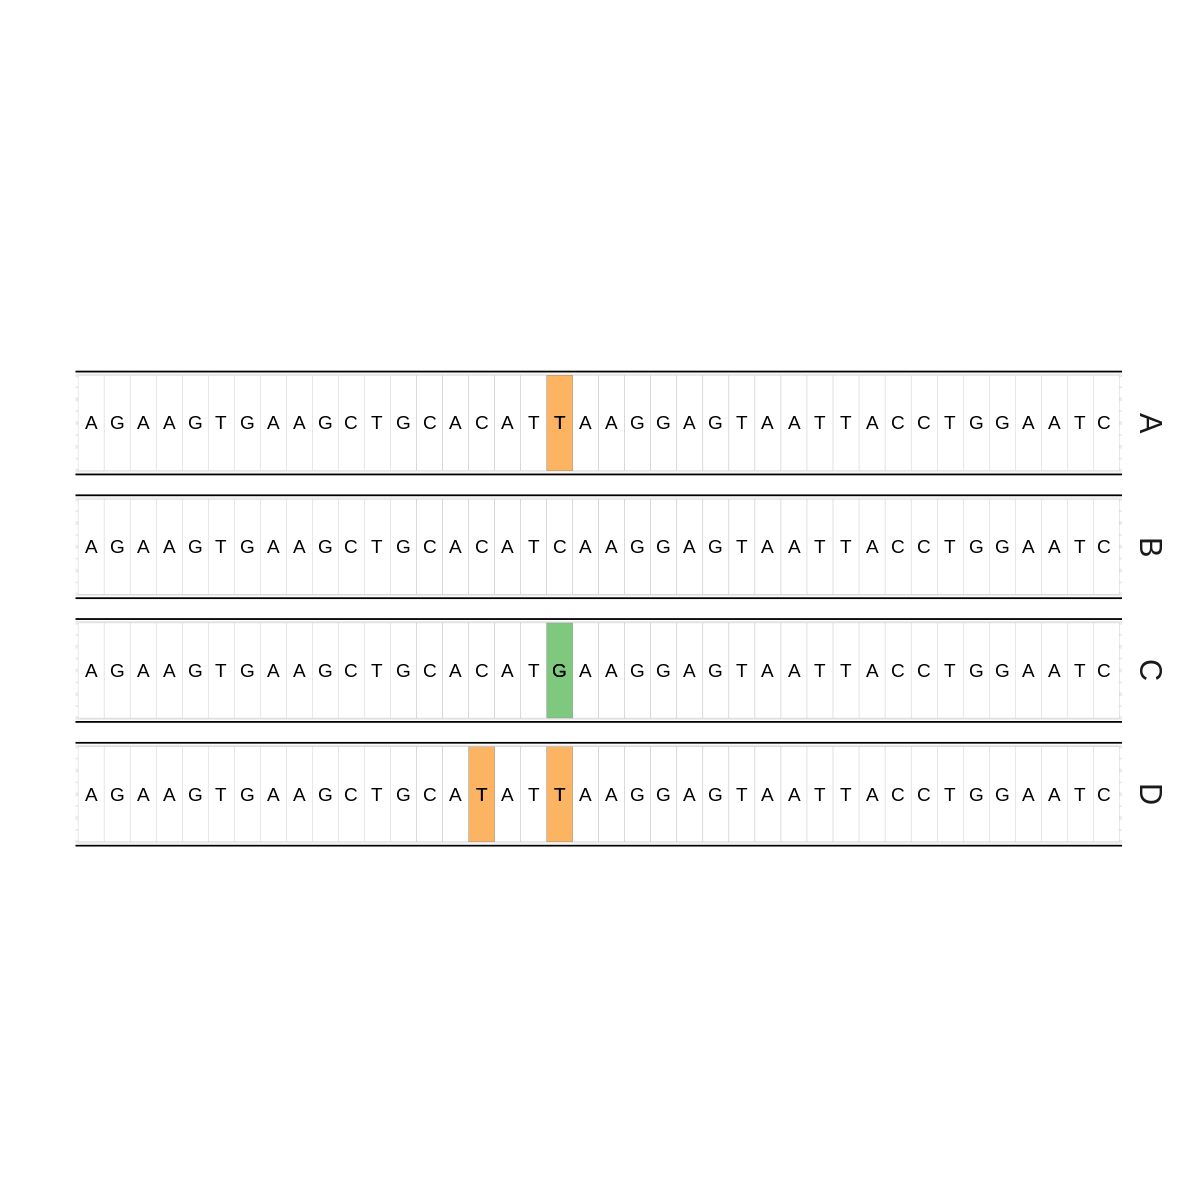

In [102]:
alleles_filt_sub %>% Plotting_Alleles(ref= reference_trunc)

In [115]:
# Assign genotypes to each cell
genos <- Genotyping_Cells(alleles_filt_sub, "cell_id")
genos %>% head(2)

# Define dosage based on expected alleles
genos = genos %>% mutate(dosage = ifelse(AllelicGenotype == "B", 0, 
                                 ifelse(AllelicGenotype == "A", 2, 
                                        ifelse(AllelicGenotype == 'AB', 1, NA))))
genos$AllelicGenotype %>% table
genos$dosage %>% table

cell_id,genotype,AllelicGenotype
<chr>,<chr>,<chr>
AACATCTCTGTGAC_ACAGTTCCAG,AGAAGTGAAGCTGCACATTAAGGAGTAATTACCTGGAATC,A
AACATCTCTGTGAC_CCGCATATTC,AGAAGTGAAGCTGCACATTAAGGAGTAATTACCTGGAATC,A


.
  A  AB  AC  AD   B  BC  BD   C   D 
157 160   2   2 266   8   3   4   2 

.
   0    1    2 <NA> 
 266  160  157   21 

In [9]:
write_csv(genos, "../../../Experiments/20230525/GithubExample/genotypes.csv")

# 4. Linear modeling

Next, we modeled raw gene and protein expression with a negative binomial linear model. For specific figures/experiments, please refer to the corresponding notebook in the `figures` directory.

Please note that plate barcodes may be different between each modality (DNA, RNA, ADT) based on plate barcodes utilized in library prep and sequencing. Similarly, cell IDs may be referred to by cell barcode or plate well (e.g. A1). In the sample processed data, we have standardized barcodes between modalities, but similar standardization may be needed for new query datasets depending on sequencing methods. 

In [2]:
meta = read_delim('../../../Experiments/Data_Submission/GEO/geo_scRNA_ADT_seq/metadata_PTPRC_filt.csv') %>% as.data.frame
counts = readRDS('../../../Experiments/Data_Submission/GEO/geo_scRNA_ADT_seq/exprsRNA_PTPRC.rds')
prots = readRDS('../../../Experiments/Data_Submission/GEO/geo_scRNA_ADT_seq/countsADT_PTPRC.rds')

Rows: 605 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (5): cell, plate, genotype, allelic_genotype, condition
dbl (6): nUMI_ADT, nADTs, nUMI_RNA, nGenes, dosage, individual_index

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [3]:
genos = read_delim("../../../Experiments/20230525/GithubExample/genotypes.csv") %>% as.data.frame

Rows: 604 Columns: 4
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): cell_id, genotype, AllelicGenotype
dbl (1): dosage

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Data published to Zenodo already has dosages and genotypes provided. We'll remove the dosage column in this example, analogous to a pipeline being newly performed on new data.

In [5]:
meta = meta %>% dplyr::select(-c(dosage, genotype))

# Merge cell metadata (i.e. nUMI, Plate, Editing condition, sample) with genotypes
meta = merge(meta, genos, by.x = 'cell', by.y = 'cell_id', all.x = TRUE)

While the published data on Zenodo has already been QCed, we would next peform QC on RNA and ADT separately. We utilized number of UMI, number of Genes per cell, percent mitochondrial reads per cell, and genes expressed in > 10 cells for QC. Please refer to [Seurat's Tutorial](https://satijalab.org/seurat/articles/pbmc3k_tutorial.html) for a framework of scRNA QC or [our notebook](../figures/PTPRC/PTPRC_Github.ipynb) detailing this analysis of CD45/PTPRC for the quality control metrics utilized.


**1. RNA modeling effects of dosage in edited cells**

In [6]:
meta_lm = meta[!(is.na(meta[['dosage']])), ] %>% filter(condition == 'Edited')
meta_lm = meta_lm %>% rename(Dosage = dosage, Edited_Index = condition, Individual_Index = individual_index,
                            `nUMI.y` = nUMI_RNA, Plate = plate)
# Subset to relevant cells
Exprs <- counts[, meta_lm$cell]

In [7]:
df <- meta_lm
cells <- df$cell
df$Individual_Index <- as.factor(df$Individual_Index)
df$Dosage %>% table

nCells = rowSums(Exprs > 0)
gene_qc = data.frame(nCells = nCells %>% sort %>% rev, rank = seq(1, length(nCells)))

#Only test genes expressed in 15% of cells
Exprs <- Exprs[gene_qc %>% filter(nCells > length(cells)*0.15) %>% rownames, cells]
genes <- rownames(Exprs)

.
  0   1   2 
225 155 157 

In [8]:
res_Dosage = data.frame()

for (i in genes){
    tryCatch({
    lm0 = glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1 + log10(nUMI.y) + Plate + Individual_Index)    
    lm1 = glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1  + log10(nUMI.y) + Plate + Individual_Index + Dosage)  
    res = data.frame(c("gene" = i, coefficients(lm1), "pval" = anova(lm0, lm1, test = "Chisq")[2, 'Pr(Chi)'])) %>% t %>% as.data.frame
    rownames(res) = NULL
    res_Dosage = rbind(res_Dosage, res)    
    }, error = function(e){
        print(e$message)
    })
}

res_Dosage = res_Dosage %>% mutate(padjBH = p.adjust(pval, method = "BH"))
rownames(res_Dosage) = res_Dosage$gene

Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, m

[1] "no valid set of coefficients has been found: please supply starting values"


Warning message:
“glm.fit: algorithm did not converge”
Warning message in glm.nb(data = df, formula = (Exprs)[i, ] ~ 1 + log10(nUMI.y) + :
“alternation limit reached”
Warning message:
“glm.fit: algorithm did not converge”
Warning message in glm.nb(data = df, formula = (Exprs)[i, ] ~ 1 + log10(nUMI.y) + :
“alternation limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message:
“glm.fit: algorithm did not converge”
Warning message in glm.nb(data = df, formula = (Exprs)[i, ] ~ 1 + log10(nUMI.y) + :
“alternation limit reached”
Warning message

In [9]:
res_Dosage %>% filter(padjBH < 0.05) %>% arrange(desc(Dosage))

,gene,(Intercept),log10(nUMI.y),PlateP3,PlateP4,Individual_Index10038222,Individual_Index10049338,Dosage,pval,padjBH
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
ANXA3,ANXA3,-13.3146169333457,2.52836986053596,0.264189045583971,0.0276267106598047,0.923221768588415,0.362937556885167,0.870316151592614,3.99582391619191e-08,1.117432e-04
CHCHD10,CHCHD10,-10.158598998045,2.63791537775415,-0.157073278946548,0.0707855315931487,-0.268526663187239,0.00382373725234504,0.361134493662655,2.08807917601028e-06,3.892876e-03
MT-ND4,MT-ND4,-4.81727254339369,2.16487885441782,0.319323983581525,0.303517516056066,-0.134478252640819,-0.0243262890392478,0.118023153540244,1.33671202482422e-05,1.495246e-02
PTPRC,PTPRC,-9.24123537235833,2.47428563178816,0.283550978747193,0.202764285404296,-0.209674074606085,-0.249709229437769,-0.661331446032439,4.44089209850063e-16,2.483791e-12
TNFRSF4,TNFRSF4,-4.24725954382211,1.98230782828782,0.0632862426821144,0.165268694797043,-0.159356510781774,0.122132406406239,-0.271307910423315,3.41731945352475e-06,4.778267e-03
TRBC2,TRBC2,-5.85622514351316,2.22967849893647,0.202957490776555,0.115282118258077,-0.41614949669234,-0.088248718845243,-0.242777807574833,3.90553394544746e-05,3.640609e-02


**2. ADT modeling effects of dosage in edited cells**

In [10]:
meta_lm = meta[!(is.na(meta[['dosage']])), ] %>% filter(condition == 'Edited')
meta_lm = meta_lm %>% rename(Dosage = dosage, Edited_Index = condition, Individual_Index = individual_index,
                            `nUMI.y` = nUMI_RNA, Plate = plate)
# Subset to relevant cells
Exprs <- prots[, meta_lm$cell]

In [11]:
df <- meta_lm
cells <- df$cell
df$Individual_Index <- as.factor(df$Individual_Index)
df$Dosage %>% table
genes = rownames(Exprs)
genes <- genes[-grep(genes, pattern = "^Ig")] #Remove Ig prots

.
  0   1   2 
225 155 157 

In [12]:
length(genes)

[1] 158

In [13]:
res_DosageADT = data.frame()

for (i in genes){
    tryCatch({
    lm0 = glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1 + log10(nUMI.y) + Plate + Individual_Index)    
    lm1 = glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1  + log10(nUMI.y) + Plate + Individual_Index + Dosage)  
    res = data.frame(c("gene" = i, coefficients(lm1), 
                       "pval" = anova(lm0, lm1, test = "Chisq")[2, 'Pr(Chi)'])) %>% t %>% as.data.frame
    rownames(res) = NULL
    res_DosageADT = rbind(res_DosageADT, res)    
    }, error = function(e){
        print(e$message)
    })
}

res_DosageADT = res_DosageADT %>% mutate(padjBH = p.adjust(pval, method = "BH"))
rownames(res_DosageADT) = res_DosageADT$gene

Warning message in glm.nb(data = df, formula = (Exprs)[i, ] ~ 1 + log10(nUMI.y) + :
“alternation limit reached”
Warning message in glm.nb(data = df, formula = (Exprs)[i, ] ~ 1 + log10(nUMI.y) + :
“alternation limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message:
“glm.fit: algorithm did not converge”
Warning message in glm.nb(data = df, formula = (Exprs)[i, ] ~ 1 + log10(nUMI.y) + :
“alternation limit reached”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message

[1] "NA/NaN/Inf in 'x'"


Warning message:
“step size truncated due to divergence”


[1] "NA/NaN/Inf in 'x'"


Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in sqrt(1/i):
“NaNs produced”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message in glm.nb(data = df, formula = (Exprs)[i, ] ~ 1 + log10(nUMI.y) + :
“alternation limit reached”


In [14]:
res_DosageADT %>% filter(padjBH < 0.05) %>% arrange(desc(Dosage))

,gene,(Intercept),log10(nUMI.y),PlateP3,PlateP4,Individual_Index10038222,Individual_Index10049338,Dosage,pval,padjBH
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
CD4,CD4,-2.01187719483603,1.23768727122701,0.932850383635162,0.811435125712358,-0.0666467014867596,-0.164516621969085,0.300593293783451,0,0.000000e+00
CD26,CD26,-1.64704685175264,0.913378025559195,1.00541394969929,1.15497839358331,-0.163758971465638,0.54165006446121,0.249329914531922,4.68629808979548e-05,7.310625e-04
CD71,CD71,-0.565352223847758,1.65161327777227,0.884187671575844,0.876904851843037,-0.52516385910761,-0.189563647840751,0.245757573110838,4.20569690184891e-09,1.312177e-07
CD28,CD28,-4.29570902942623,1.23834565811634,0.720730782147684,0.70981776079437,-0.320795051801018,-0.0950624834202759,0.190559912744519,1.3535095583328e-05,3.016393e-04
Integrin_β7,Integrin_β7,-1.03178720494589,0.862886533687191,0.99609813462467,0.728266991074799,0.193024076862585,0.226551178749573,0.168041082904595,0.00107561894261965,1.048728e-02
CD18,CD18,-3.63404557842916,1.12308131830603,0.821938638850082,0.600569117902295,0.0347408153277544,-0.182892391318473,0.155742300933709,0.00013134610459975,1.547758e-03
CD183,CD183,-1.0803411189513,0.906783210562976,0.884659055952837,0.955796034776726,-0.36454115374672,0.402249474215411,0.155279641927742,4.09023783175533e-05,7.089746e-04
CD101,CD101,-2.55656143111058,0.75798413936295,0.98519737849816,1.15863216607544,-0.014654317738528,0.42650089525783,0.146782680893379,0.00212904336013453,1.845171e-02
CD37,CD37,-3.9800392925037,1.33522770216392,0.984560993531937,1.02466956231723,-0.303554481950882,-0.00406782448746069,0.145469844687092,3.29927222264548e-05,6.433581e-04


**3. RNA modeling effects of editing condition on all cells**

In [15]:
meta_lm = meta
meta_lm = meta_lm %>% rename(Dosage = dosage, Edited_Index = condition, Individual_Index = individual_index,
                            `nUMI.y` = nUMI_RNA, Plate = plate)
meta_lm = meta_lm[!is.na(meta_lm['Edited_Index']), ]
# Subset to relevant cells
Exprs <- counts[, meta_lm$cell]

In [16]:
df <- meta_lm
cells <- df$cell
df$Individual_Index <- as.factor(df$Individual_Index)
df$Dosage %>% table

nCells = rowSums(Exprs > 0)
gene_qc = data.frame(nCells = nCells %>% sort %>% rev, rank = seq(1, length(nCells)))

#Only test genes expressed in 15% of cells
Exprs <- Exprs[gene_qc %>% filter(nCells > length(cells)*0.15) %>% rownames, cells]
genes <- rownames(Exprs)

.
   0    1    2 <NA> 
 266  156  157   22 

In [17]:
res_Condition = data.frame()

for (i in genes[1:50]){
    tryCatch({
    lm0 = glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1 + log10(nUMI.y) + Plate + Individual_Index)    
    lm1 = glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1  + log10(nUMI.y) + Plate + Individual_Index + Edited_Index)  
    res = data.frame(c("gene" = i, coefficients(lm1), 
                       "pval" = anova(lm0, lm1, test = "Chisq")[2, 'Pr(Chi)'])) %>% t %>% as.data.frame
    rownames(res) = NULL
    res_Condition = rbind(res_Condition, res)    
    }, error = function(e){
        print(e$message)
    })
}

res_Condition = res_Condition %>% mutate(padjBH = p.adjust(pval, method = "BH"))
rownames(res_Condition) = res_Condition$gene

In [18]:
res_Condition %>% filter(padjBH < 0.05) %>% arrange(desc(Edited_IndexEdited))

,gene,(Intercept),log10(nUMI.y),PlateP3,PlateP4,Individual_Index10038222,Individual_Index10049338,Edited_IndexEdited,pval,padjBH
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
MALAT1,MALAT1,-1.46587641318462,1.37070132719764,-0.0579415389444933,0.0469173628554639,-0.385971839700164,-0.0281238973917854,0.34241055048019,0.00673474077672698,0.0240526456
RPS3,RPS3,-4.18697734781091,1.95452554635265,-0.101437018968753,-0.0661013288498644,-0.0513237978795703,0.0491910282620044,0.281029685138646,2.49646157213235e-06,0.0001248231
RPS12,RPS12,-4.47633409001125,1.84746416560505,-0.789433714082778,-0.39637555949438,-0.150369433209654,-0.00711284994821321,0.231736270414299,0.0002685061564629,0.0033563270
RPL13,RPL13,-3.40827340920651,2.08954522259492,-0.412897673891771,-0.165013890150849,-0.109241867306495,0.0336415874037237,0.231438750505786,6.29064482038366e-06,0.0001572661
RPL4,RPL4,-6.95016379759061,2.69898023232177,0.224881065917772,0.12826781512917,-0.0267982005969365,-0.0037146597958083,0.229377276650031,0.000646112293963386,0.0064611229
RPS2,RPS2,-3.71372020525509,2.15354106531695,-0.0590405985954662,-0.0914869486230736,-0.0277111919217986,0.0704468209320082,0.223189034633391,6.63848494756314e-05,0.0011064142
RPL11,RPL11,-4.47632103309392,1.83943863105275,-0.635352276957047,-0.349553896006124,-0.0608535515904556,-0.0445155722401239,0.200456559950069,0.00166916047321908,0.0084881610
RPL13A,RPL13A,-3.51699484399442,1.80961421236669,-0.320621488707243,-0.209504930234762,-0.0171143151170239,-0.0167204237409474,0.197551789041008,0.00166116322187804,0.0084881610
EEF1G,EEF1G,-5.65083094513458,2.23156162712368,0.103020934444579,0.0494883691723357,-0.174722686416061,-0.0955885538658461,0.193377433333232,0.00257108650410542,0.0107128604


**4. ADT modeling effects of editing condition on all cells**

In [19]:
meta_lm = meta
meta_lm = meta_lm %>% rename(Dosage = dosage, Edited_Index = condition, Individual_Index = individual_index,
                            `nUMI.y` = nUMI_RNA, Plate = plate)
meta_lm = meta_lm[!is.na(meta_lm['Edited_Index']), ]
# Subset to relevant cells
Exprs <- prots[, meta_lm$cell]

In [20]:
df <- meta_lm
cells <- df$cell
df$Individual_Index <- as.factor(df$Individual_Index)
df$Dosage %>% table
genes = rownames(Exprs)
genes <- genes[-grep(genes, pattern = "^Ig")] #Remove Ig prots

.
   0    1    2 <NA> 
 266  156  157   22 

In [21]:
length(genes)

[1] 158

In [22]:
res_ConditionADT = data.frame()

for (i in genes){
    tryCatch({
    lm0 = glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1 + log10(nUMI.y) + Plate + Individual_Index)    
    lm1 = glm.nb(data = df,  
          formula = (Exprs)[i,] ~ 1  + log10(nUMI.y) + Plate + Individual_Index + Edited_Index)  
    res = data.frame(c("gene" = i, coefficients(lm1), 
                       "pval" = anova(lm0, lm1, test = "Chisq")[2, 'Pr(Chi)'])) %>% t %>% as.data.frame
    rownames(res) = NULL
    res_ConditionADT = rbind(res_ConditionADT, res)    
    }, error = function(e){
        print(e$message)
    })
}

res_ConditionADT = res_ConditionADT %>% mutate(padjBH = p.adjust(pval, method = "BH"))
rownames(res_ConditionADT) = res_ConditionADT$gene

Warning message in glm.nb(data = df, formula = (Exprs)[i, ] ~ 1 + log10(nUMI.y) + :
“alternation limit reached”
Warning message in glm.nb(data = df, formula = (Exprs)[i, ] ~ 1 + log10(nUMI.y) + :
“alternation limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message in theta.ml(Y, mu, sum(w), w, limit = control$maxit, trace = control$trace > :
“iteration limit reached”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:
“glm.fit: algorithm did not converge”
Warning message:


[1] "NA/NaN/Inf in 'x'"


Warning message:
“step size truncated due to divergence”


[1] "NA/NaN/Inf in 'x'"


In [23]:
res_ConditionADT %>% filter(padjBH < 0.05) %>% arrange(desc(Edited_IndexEdited))

,gene,(Intercept),log10(nUMI.y),PlateP3,PlateP4,Individual_Index10038222,Individual_Index10049338,Edited_IndexEdited,pval,padjBH
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
CD72,CD72,-2.6048871532285,0.79284873245247,0.942355457721677,0.897992349742168,0.814300915525534,0.386872075607029,0.800542422313748,0.000239309386478426,0.008099913
GPR56,GPR56,-1.8629922643546,0.718542378320897,0.607929643332515,0.739565897795861,-0.379067274773981,0.190936032178965,0.624168543677076,0.000276914292038688,0.008099913
CD7,CD7,-3.20537941841659,1.23036871992481,0.997892702861559,1.03468077346687,-0.441199239632854,0.0922817643433814,0.521230840310168,2.82156746359563e-05,0.002200823
CD274,CD274,0.72662845429214,0.183644408584019,1.19975486578843,1.49059833406869,-0.305326062384316,0.839476237612234,0.509087487345,0.00325479843287302,0.046158960
CD25,CD25,-1.83815998160317,1.16141434389872,0.985880076671366,0.893916095487123,0.019147382148265,0.0462104830518209,0.506484190440599,8.68660423980483e-06,0.001355110
Rat_IgG2c_K,Rat_IgG2c_K,-4.29866570527917,1.04902459642766,0.961265231100252,0.981341857230931,-0.220535696759923,0.202970425316726,0.426361414373774,0.00273829503653267,0.046158960
CD279,CD279,1.5345617215892,0.922773237575845,0.92015519697631,0.836187140398045,0.0335659835093928,0.286573832834596,0.420894476106219,0.000311535116120254,0.008099913
CD137,CD137,-4.55404757774471,1.44066511085324,1.11975011076117,1.24388900160976,0.14054719453702,0.25588260772595,0.417163597154953,0.00306474580875538,0.046158960
CD4,CD4,-2.93021336171772,1.42176396079832,0.957351185808168,0.850193069110707,-0.0485907535972853,-0.061308298014933,0.391873093096563,0.000128816980653257,0.006698483


# 6. End

In [61]:
sessionInfo()

R version 4.2.3 (2023-03-15)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /PHShome/mc1070/anaconda3/envs/seurat5_env/lib/libopenblasp-r0.3.27.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] Matrix_1.6-5      lubridate_1.9.3   forcats_1.0.0     stringr_1.5.1    
 [5] dplyr_1.1.4       purrr_1.0.2       readr_2.1.5       tidyr_1.3.1      
 [9] tibble_3.2.1      ggplot2_3.5.1     tidyverse_2.0.0   patchwork_1.2.0  
[13] magrittr_2.0.3    data.table_1.15.2 dendsort_0.3.4   

loa